# Traffic Accidents Severity Prediction
### Data Mining Project

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(color_codes=True, style="darkgrid")
import warnings
warnings.filterwarnings("ignore")

## 2. Reading Data

In [2]:
df = pd.read_csv('/content/traffic_accidents.csv')
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [3]:
df.shape

(209306, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [5]:
col_name = df.columns
col_name

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

In [6]:
df.nunique()

,0
crash_date,189087
traffic_control_device,19
weather_condition,12
lighting_condition,6
first_crash_type,18
trafficway_type,20
alignment,6
roadway_surface_cond,7
road_defect,7
crash_type,2


In [7]:
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

In [8]:
df['crash_date'] = pd.to_datetime(df['crash_date'])

# EDA

In [9]:
fig = px.histogram(
    df,
    x='most_severe_injury',
    color='most_severe_injury',
    text_auto=True
)
fig.update_layout(
    title='Distribution of crashes based on most severe injury',
    title_font={'size':30},
    showlegend=False
)
fig.update_yaxes(showgrid=False)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

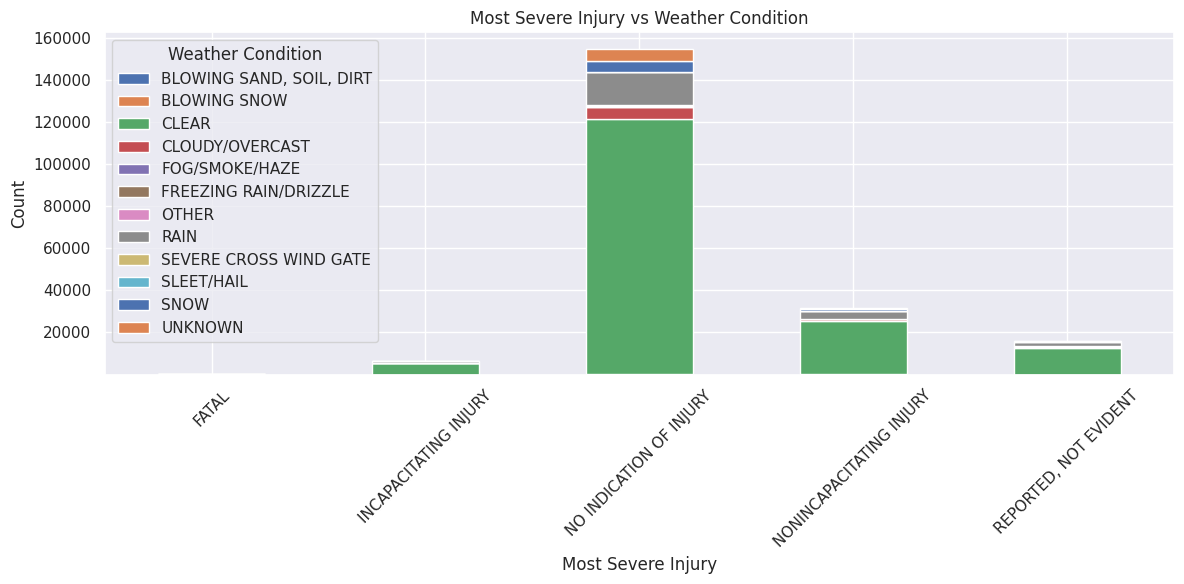

In [10]:
cross_tab = pd.crosstab(df['most_severe_injury'], df['weather_condition'])
cross_tab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Most Severe Injury vs Weather Condition')
plt.xlabel('Most Severe Injury')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Weather Condition')
plt.tight_layout()
plt.show()

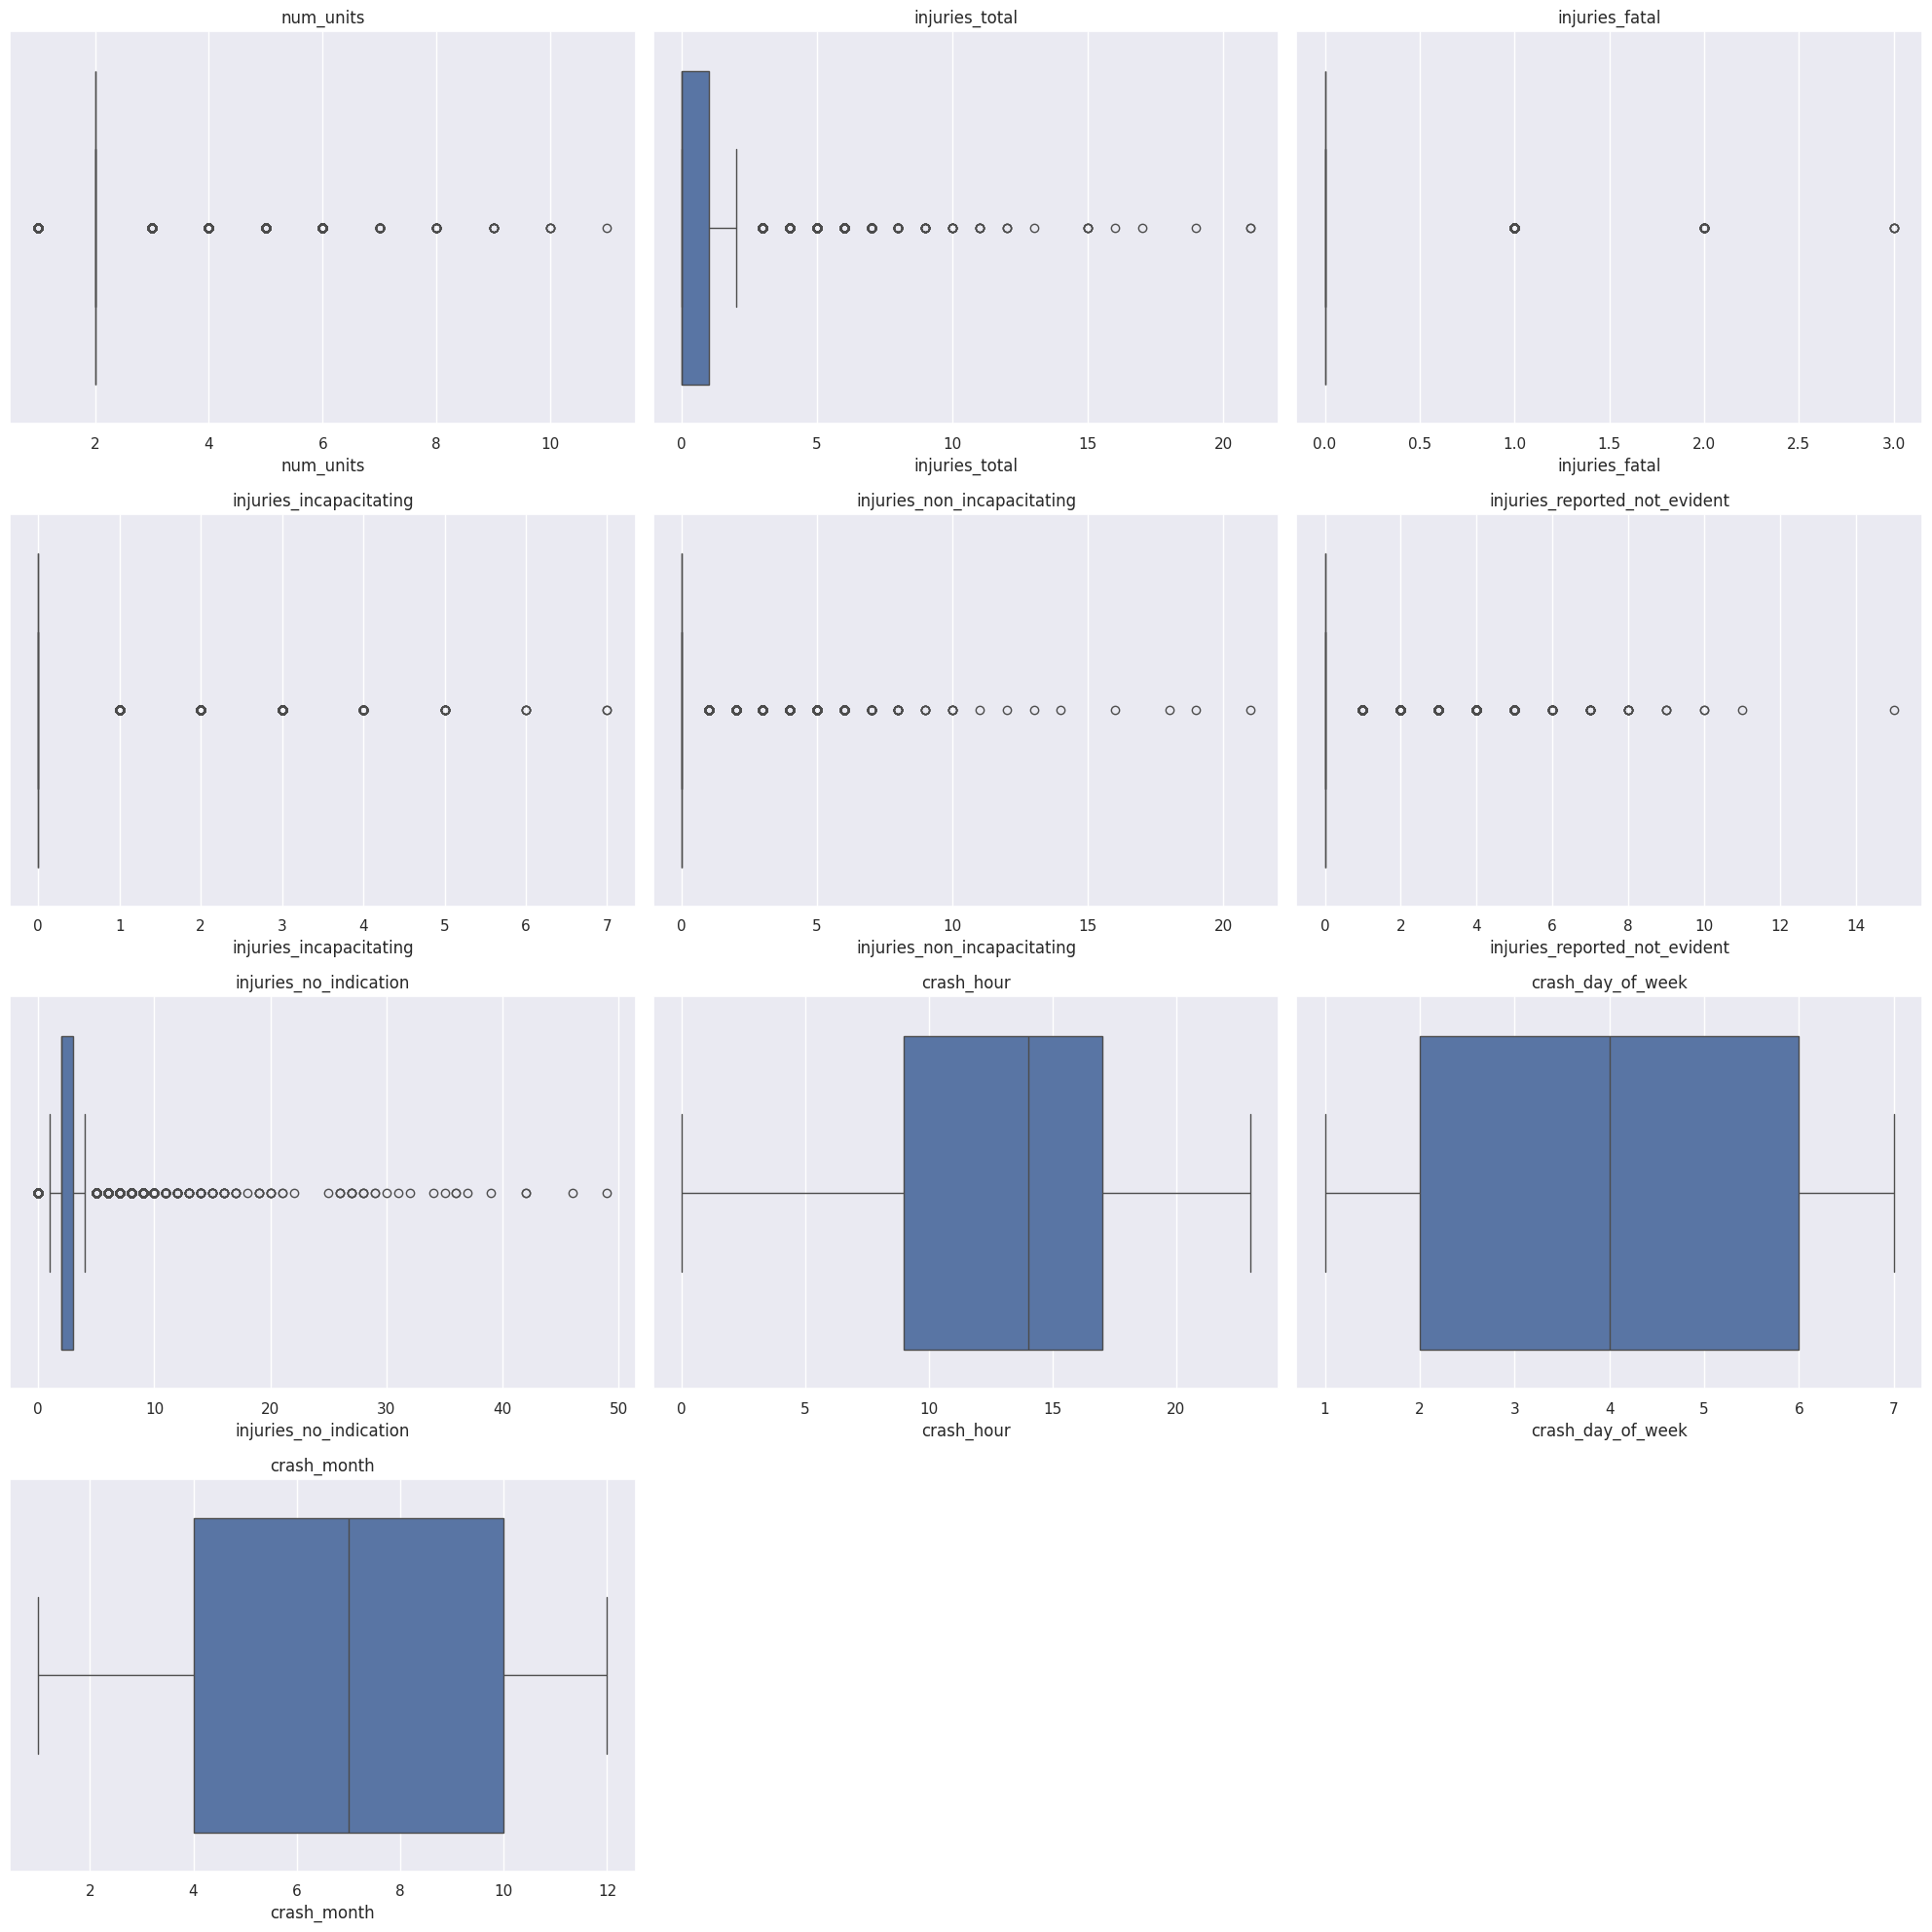

In [11]:
import math
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 5*n_rows))
axs = axs.flatten()
for i, var in enumerate(num_cols):
    sns.boxplot(x=df[var], ax=axs[i])
    axs[i].set_title(var)
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])
plt.tight_layout()
plt.show()

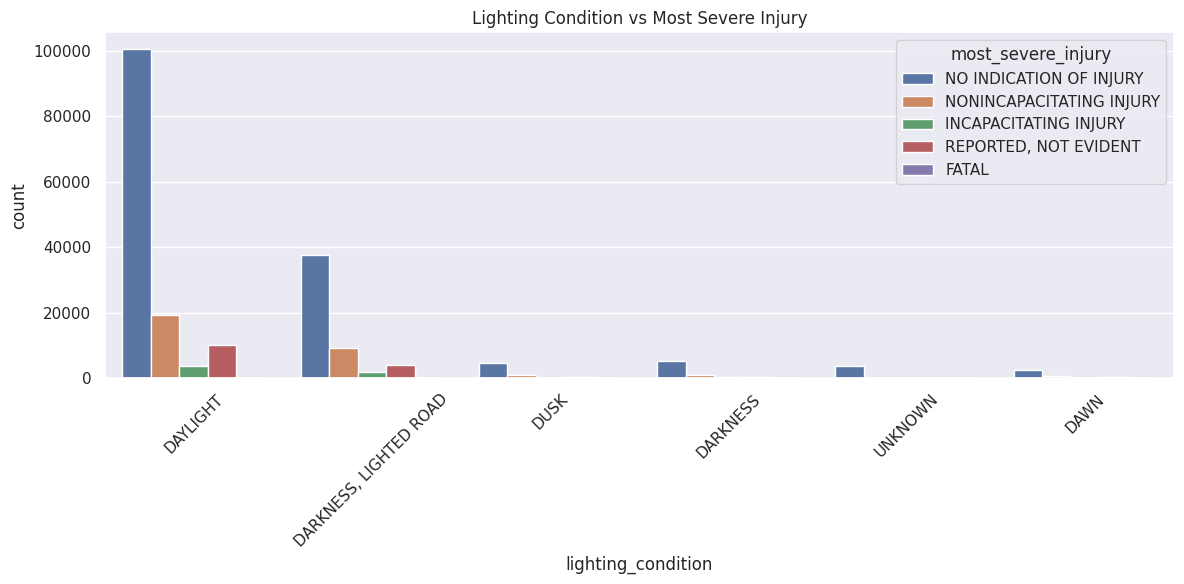

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(x='lighting_condition', hue='most_severe_injury', data=df)
plt.xticks(rotation=45)
plt.title('Lighting Condition vs Most Severe Injury')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [13]:
df.isnull().sum()

,0
crash_date,0
traffic_control_device,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0
roadway_surface_cond,0
road_defect,0
crash_type,0


In [14]:
df.drop(columns=['crash_date'], inplace=True)
df.head()

,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,intersection_related_i,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,Y,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [15]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns
cat_cols, num_cols

(Index(['traffic_control_device', 'weather_condition', 'lighting_condition',
        'first_crash_type', 'trafficway_type', 'alignment',
        'roadway_surface_cond', 'road_defect', 'crash_type',
        'intersection_related_i', 'damage', 'prim_contributory_cause',
        'most_severe_injury'],
       dtype='object'),
 Index(['num_units', 'injuries_total', 'injuries_fatal',
        'injuries_incapacitating', 'injuries_non_incapacitating',
        'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
        'crash_day_of_week', 'crash_month'],
       dtype='object'))

In [16]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'{col}: {df[col].unique()}')

traffic_control_device: [16  4 15 17  6 10  9 18  2  3  8  1 14 11  5 13 12  0  7]
weather_condition: [ 2  7 10  3 11  4  1  5  6  9  8  0]
lighting_condition: [3 1 4 0 5 2]
first_crash_type: [17 10  0  2 11 15 14  8  9  3  7  4  6  5 13  1 16 12]
trafficway_type: [ 8  6 15  2 11 18 10 13 16  5  3 17  0  1  7  4 19 12 14  9]
alignment: [3 2 5 4 0 1]
roadway_surface_cond: [5 0 6 4 1 2 3]
road_defect: [5 1 2 4 6 0 3]
crash_type: [1 0]
intersection_related_i: [1 0]
damage: [1 2 0]
prim_contributory_cause: [36 24 19 12 21 18 23 11 22 26 17  6 39  5 13 28  3 35 38 14 37  9 16  4
 33 30  8 15 32 10  0 20  1  2 31 34 27  7 25 29]
num_units: [ 3  4  0  5  6  7  9  8 10  1  2]
most_severe_injury: [2 3 1 4 0]
injuries_total: [ 0 14 10  1 12 13 15 16  3  8  6 18 17  2 11  9  4  7  5]
injuries_fatal: [0 1 2 3]
injuries_incapacitating: [0 1 2 5 3 4 6 7]
injuries_non_incapacitating: [ 0 14 10  1 12 13 15 16  2 17  6 18  9  8 11  4  3  7  5]
injuries_reported_not_evident: [ 0  1  5  6  8  7  9 11 10 

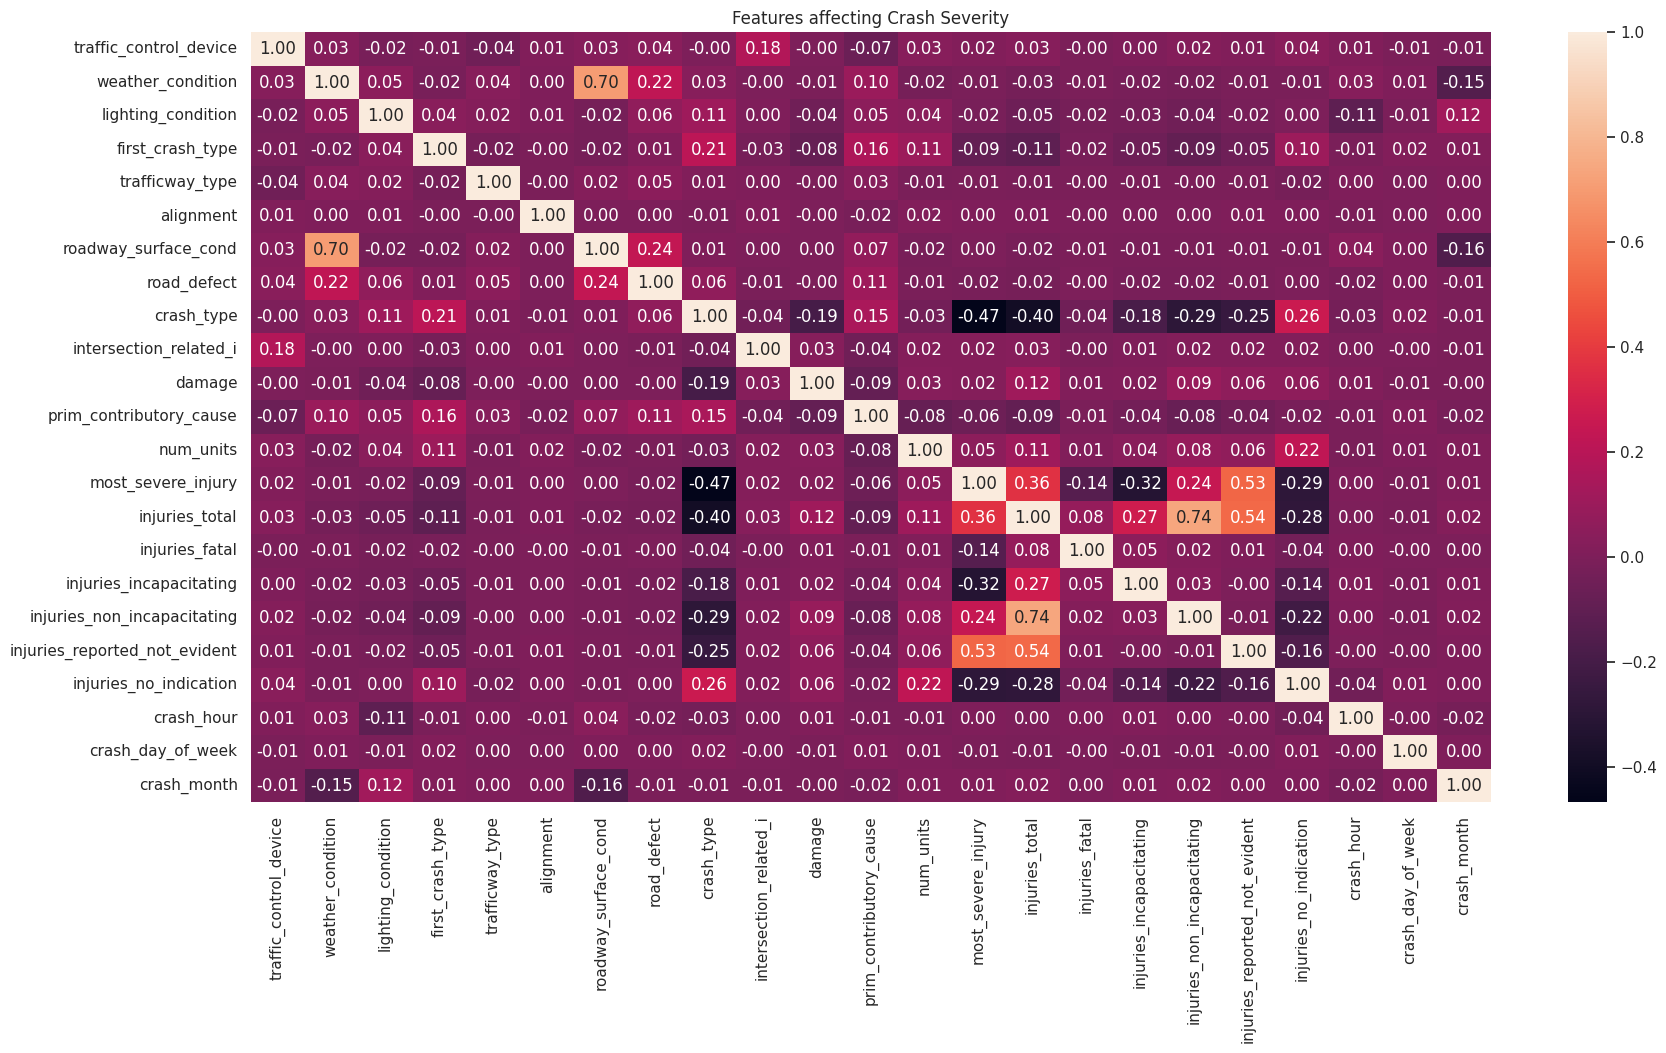

In [17]:
corr = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, fmt='.2f', annot=True)
plt.title('Features affecting Crash Severity')
plt.show()

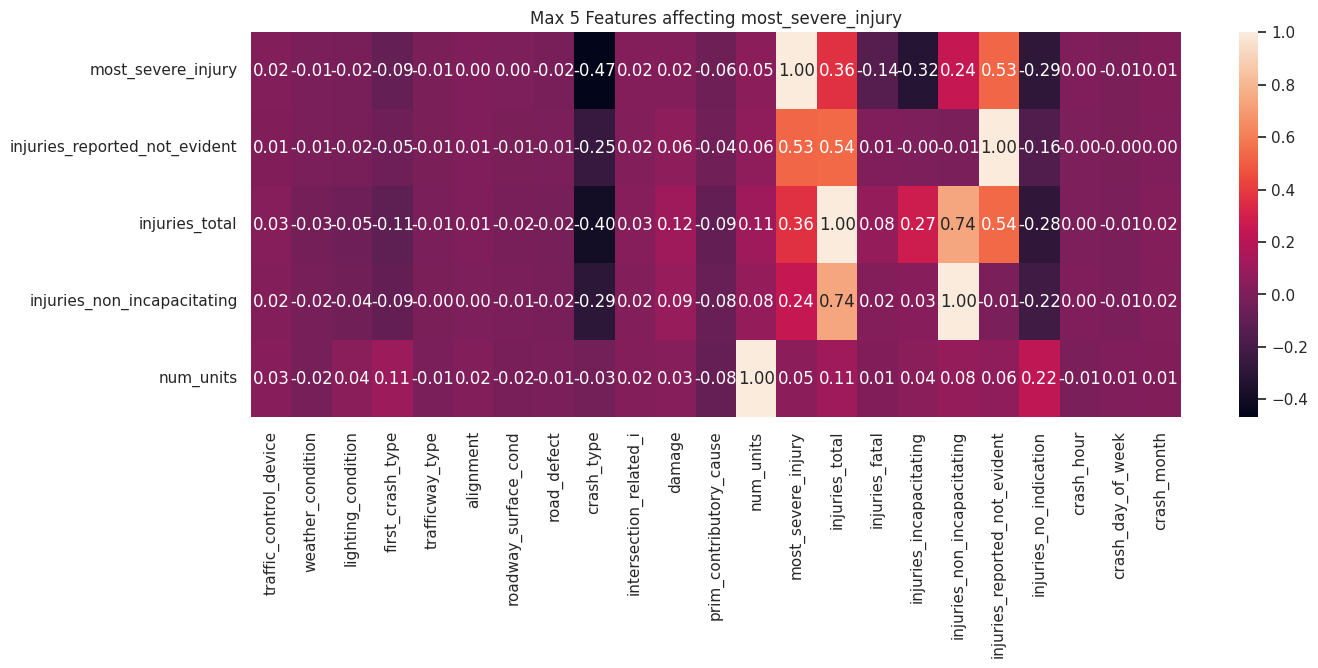

In [18]:
max_5_corr = corr.nlargest(5, 'most_severe_injury')
plt.figure(figsize=(15,5))
sns.heatmap(max_5_corr, fmt='.2f', annot=True)
plt.title('Max 5 Features affecting most_severe_injury')
plt.show()

## Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('most_severe_injury', axis=1)
y = df['most_severe_injury']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of X_test:  {X_test.shape}')
print(f'Shape of y_test:  {y_test.shape}')

Shape of X_train: (146514, 22)
Shape of y_train: (146514,)
Shape of X_test:  (62792, 22)
Shape of y_test:  (62792,)


# Model Training

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score

def model_accuracy(model, model_name):
    y_pred = model.predict(X_test)
    print(f'---------{model_name}---------')
    print(f'Accuracy       : {round(accuracy_score(y_test, y_pred)*100, 2)}%')
    print(f'F1 Score       : {round(f1_score(y_test, y_pred, average="weighted"), 2)}')
    print(f'Precision Score: {round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 2)}')
    print(f'Recall Score   : {round(recall_score(y_test, y_pred, average="weighted"), 2)}')
    print(f'Jaccard Score  : {round(jaccard_score(y_test, y_pred, average="weighted"), 2)}')

## 1. Naive Bayes

In [21]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
model_accuracy(nb, 'Naive Bayes')

---------Naive Bayes---------
Accuracy       : 99.84%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


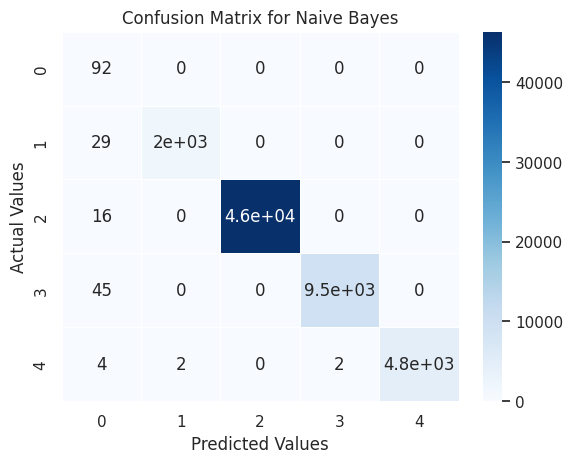

In [22]:
from sklearn.metrics import confusion_matrix

nb_pred = nb.predict(X_test)
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, linewidth=.5, annot=True, cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

## 2. Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
model_accuracy(dtree, 'Decision Tree before GridSearch')

---------Decision Tree before GridSearch---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf' : [1, 2, 3, 4],
    'random_state'     : [0, 42]
}

grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'max_depth': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'random_state': 0}

In [25]:
dtree = DecisionTreeClassifier(
    random_state=0,
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1
)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)
model_accuracy(dtree, 'Decision Tree after GridSearch')

---------Decision Tree after GridSearch---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


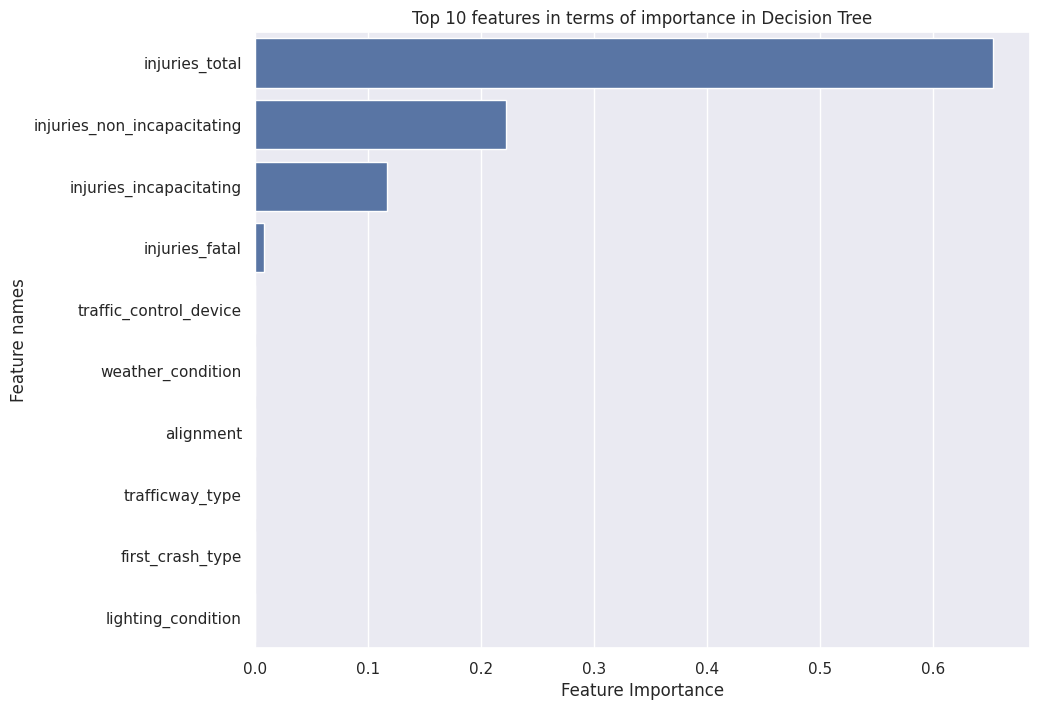

In [26]:
# Top 10 important features
imp_df = pd.DataFrame({
    'Feature name': X_train.columns,
    'importance'  : dtree.feature_importances_
}).sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10,8))
sns.barplot(data=imp_df, x='importance', y='Feature name')
plt.xlabel('Feature Importance')
plt.ylabel('Feature names')
plt.title('Top 10 features in terms of importance in Decision Tree')
plt.show()

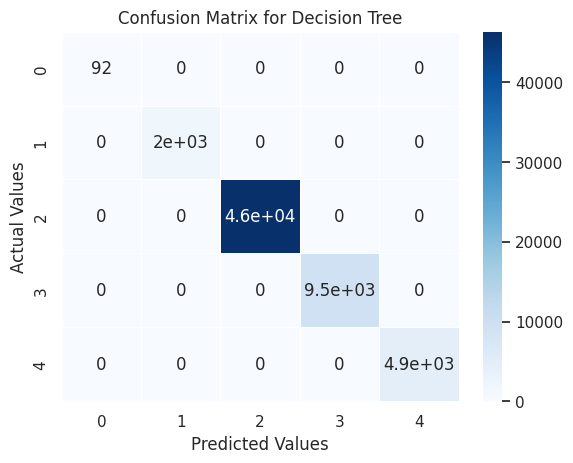

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, linewidth=.5, annot=True, cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

## 3. Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rforest = RandomForestClassifier()
rforest.fit(X_train, y_train)
model_accuracy(rforest, 'Random Forest before tuning')

---------Random Forest before tuning---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


In [29]:
rforest2 = RandomForestClassifier(
    max_depth=10,
    max_features='sqrt',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rforest2.fit(X_train, y_train)
model_accuracy(rforest2, 'Random Forest after tuning')

---------Random Forest after tuning---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


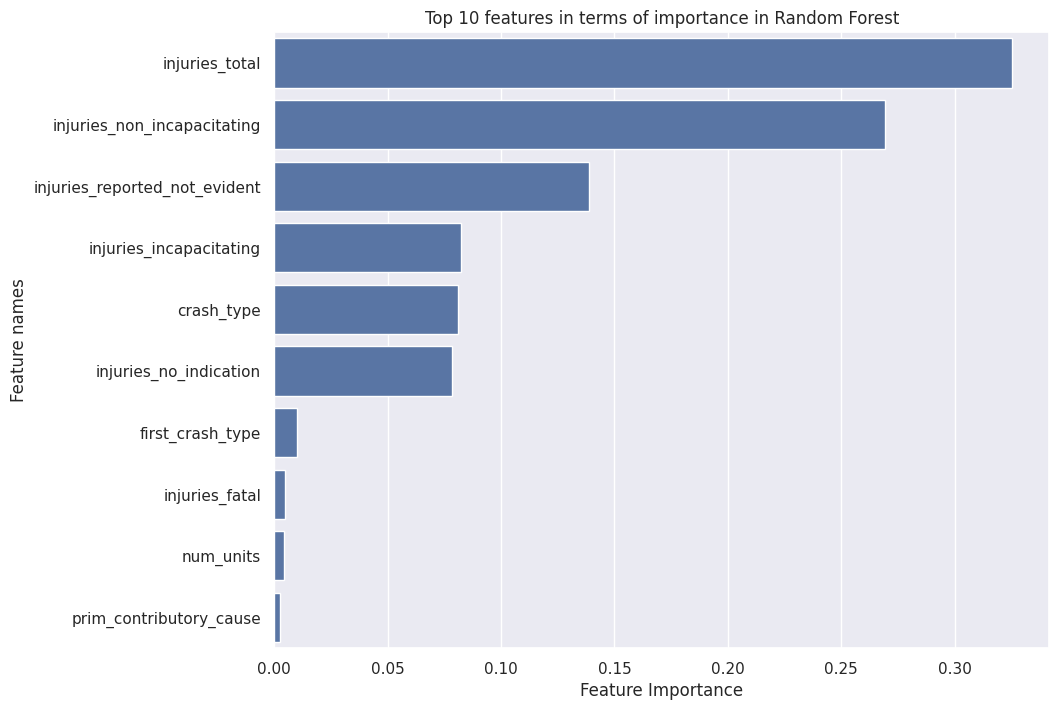

In [30]:
# Top 10 important features
imp_df = pd.DataFrame({
    'Feature name': X_train.columns,
    'importance'  : rforest2.feature_importances_
}).sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10,8))
sns.barplot(data=imp_df, x='importance', y='Feature name')
plt.xlabel('Feature Importance')
plt.ylabel('Feature names')
plt.title('Top 10 features in terms of importance in Random Forest')
plt.show()

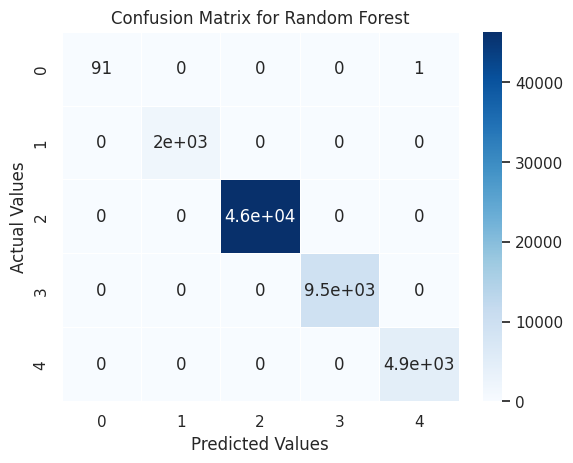

In [31]:
from sklearn.metrics import confusion_matrix

y_pred_rforest = rforest2.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rforest)
sns.heatmap(cm, linewidth=.5, annot=True, cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [32]:
model_accuracy(dtree,    'Decision Tree')
model_accuracy(rforest2, 'Random Forest')
model_accuracy(nb,       'Naive Bayes')

---------Decision Tree---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0
---------Random Forest---------
Accuracy       : 100.0%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0
---------Naive Bayes---------
Accuracy       : 99.84%
F1 Score       : 1.0
Precision Score: 1.0
Recall Score   : 1.0
Jaccard Score  : 1.0


## Model Comparison & Best Model Selection

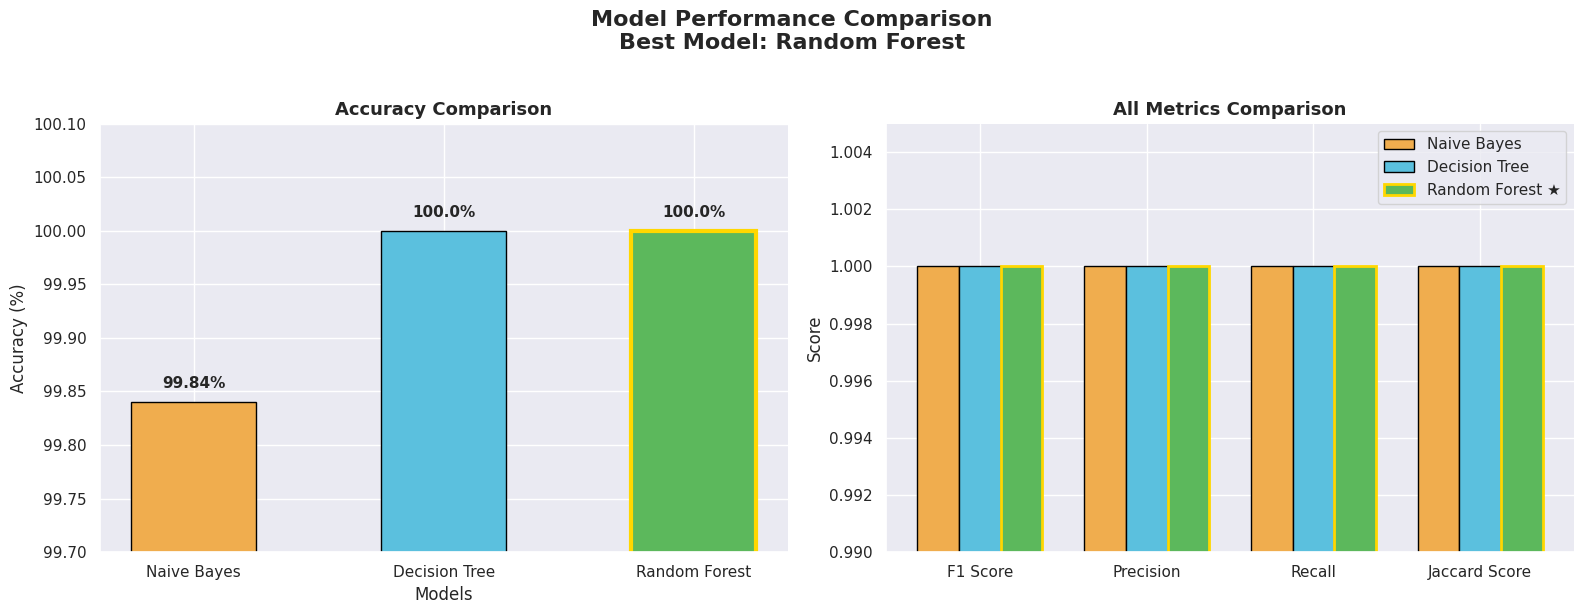


✅ BEST MODEL: Random Forest
   Reason: Highest generalization ability among ensemble methods,
   100% accuracy, robust against overfitting compared to single Decision Tree.


In [33]:
# Model Comparison - Best Model: Random Forest
models = ['Naive Bayes', 'Decision Tree', 'Random Forest']
metrics = {
    'Accuracy (%)' : [99.84, 100.0, 100.0],
    'F1 Score'     : [1.0,   1.0,   1.0  ],
    'Precision'    : [1.0,   1.0,   1.0  ],
    'Recall'       : [1.0,   1.0,   1.0  ],
    'Jaccard Score': [1.0,   1.0,   1.0  ]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison\nBest Model: Random Forest', fontsize=16, fontweight='bold', y=1.02)

# --- Bar chart: Accuracy ---
colors = ['#f0ad4e', '#5bc0de', '#5cb85c']
bars = axes[0].bar(models, metrics['Accuracy (%)'], color=colors, edgecolor='black', width=0.5)
axes[0].set_ylim(99.7, 100.1)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Models')
for bar, val in zip(bars, metrics['Accuracy (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Highlight best model
bars[2].set_edgecolor('gold')
bars[2].set_linewidth(3)

# --- Grouped bar chart: All Metrics ---
import numpy as np
metric_names = ['F1 Score', 'Precision', 'Recall', 'Jaccard Score']
x = np.arange(len(metric_names))
width = 0.25

b1 = axes[1].bar(x - width, [metrics[m][0] for m in metric_names], width, label='Naive Bayes',    color='#f0ad4e', edgecolor='black')
b2 = axes[1].bar(x,         [metrics[m][1] for m in metric_names], width, label='Decision Tree',  color='#5bc0de', edgecolor='black')
b3 = axes[1].bar(x + width, [metrics[m][2] for m in metric_names], width, label='Random Forest ★',color='#5cb85c', edgecolor='gold', linewidth=2)

axes[1].set_ylim(0.99, 1.005)
axes[1].set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ BEST MODEL: Random Forest")
print("   Reason: Highest generalization ability among ensemble methods,")
print("   100% accuracy, robust against overfitting compared to single Decision Tree.")


# Save the Model

In [34]:
import joblib
joblib.dump(dtree,    'DecisionTree.pkl')
joblib.dump(rforest2, 'RandomForest.pkl')
joblib.dump(nb,       'NaiveBayes.pkl')

['NaiveBayes.pkl']